# 02 Leave-Cohort Microglia Experiment

This notebook reads the raw h5ad from `datasets/`, extracts Microglia, selects 5000 highly expressed genes, fits full-data baselines, leaves each cohort out, and compares the missing time-point estimates against the full-data baselines.

In [1]:
from pathlib import Path
import time

import anndata as ad
import h5py
import numpy as np
import pandas as pd
import torch
import pyro
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from GP import TemporalGP
from utils import build_temporal_kernel

pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float32)

PROJECT_DIR = Path(".")
DATA_DIR = Path("datasets")
RAW_H5AD = DATA_DIR / "aging_svz_adata.h5ad"

CELL_TYPE = "Microglia"
CELLTYPE_COL = "Celltype.LowRes"
AGE_COL = "Age"
COHORT_COL = "orig.ident"

MODEL_NAMES = ["GP_MF", "GP_Full-rank", "Indep_MF"]
MODEL_LABELS = {
    "GP_MF": "GP+MF",
    "GP_Full-rank": "GP+Full-rank",
    "Indep_MF": "Independent+MF",
}

GENE_NUM = 5000
EXAMPLE_GENES = {
    "Batch-1": "Spp1",
    "Batch-2": "Bc1",
    "Batch-3": "Ifi27l2a",
    "Batch-4": "Gm42418",
}
THRESHOLDS = [0.05, 0.1, 0.5, 1.0]

NUM_STEPS = 1000
LR = 0.005
SEED = 0
CHUNK_ROWS = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"project: {PROJECT_DIR}")
print(f"raw h5ad: {RAW_H5AD}")
print(f"device: {DEVICE}")

/home/ztanag/miniconda3/envs/sctm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project: .
raw h5ad: datasets/aging_svz_adata.h5ad
device: cuda


In [2]:
adata = ad.read_h5ad(RAW_H5AD, backed="r")
obs = adata.obs[[CELLTYPE_COL, AGE_COL, COHORT_COL]].copy()
obs["age"] = pd.to_numeric(obs[AGE_COL].astype(str), errors="raise")
obs["cell_id"] = obs.index.astype(str)
obs["row_index"] = np.arange(adata.n_obs)
obs["celltype"] = obs[CELLTYPE_COL].astype(str)
obs["cohort"] = obs[COHORT_COL].astype(str)

age_values = np.array(sorted(obs["age"].unique()), dtype=float)
age_to_index = {age: i for i, age in enumerate(age_values)}
obs["time_index"] = obs["age"].map(age_to_index).astype(int)

time_kernel, gamma_age, age_z = build_temporal_kernel(age_values)
time_points = pd.DataFrame({
    "time_index": np.arange(len(age_values), dtype=int),
    "age": age_values,
    "age_z": age_z,
})

microglia_obs = (
    obs.loc[obs["celltype"] == CELL_TYPE, ["cell_id", "row_index", "age", "time_index", "cohort"]]
    .sort_values("row_index")
    .reset_index(drop=True)
)
all_genes = adata.var_names.astype(str).to_list()
gene_to_index = {gene: i for i, gene in enumerate(all_genes)}
cohorts = sorted(microglia_obs["cohort"].astype(str).unique().tolist())
cohort_time_indices = {
    cohort: sorted(microglia_obs.loc[microglia_obs["cohort"].astype(str) == cohort, "time_index"].astype(int).unique().tolist())
    for cohort in cohorts
}

print(f"{CELL_TYPE}: {microglia_obs.shape[0]} cells, {len(all_genes)} genes, {len(age_values)} time points")
print(f"temporal kernel: {time_kernel.shape}, gamma={gamma_age:.6g}")
print(cohort_time_indices)
microglia_obs.head()

Microglia: 3844 cells, 31053 genes, 26 time points
temporal kernel: (26, 26), gamma=0.53068
{'Batch-1': [4, 6, 18, 25], 'Batch-2': [1, 5, 8, 11, 13, 15, 17, 20], 'Batch-3': [0, 3, 7, 9, 10, 19, 21], 'Batch-4': [2, 12, 14, 16, 22, 23, 24]}


,cell_id,row_index,age,time_index,cohort
0,AAACCCAGTCACCACG_1,2,29.0,25,Batch-1
1,AAACCCATCACTGAAC_1,5,20.8,18,Batch-1
2,AAACGCTGTAGGCTCC_1,11,29.0,25,Batch-1
3,AAAGGATCATTGGCAT_1,23,29.0,25,Batch-1
4,AAAGGGCAGCCGAACA_1,26,29.0,25,Batch-1


In [3]:
def _to_dense_array(x):
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x)


def _read_microglia_expression_block(row_indices, gene_names=None):
    row_indices = np.asarray(row_indices, dtype=int)
    if gene_names is None:
        gene_positions = None
    else:
        gene_positions = np.array([gene_to_index[g] for g in gene_names], dtype=int)

    blocks = []
    with h5py.File(RAW_H5AD, "r") as h5:
        X = h5["X"]
        for start in range(0, len(row_indices), CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, len(row_indices))
            # h5py allows only one fancy index vector at a time.
            block = _to_dense_array(X[row_indices[start:end], :])
            if gene_positions is not None:
                block = block[:, gene_positions]
            blocks.append(block)
    return np.vstack(blocks)


def compute_gene_sums_and_library_sizes():
    row_indices = microglia_obs["row_index"].to_numpy(dtype=int)
    gene_sums = np.zeros(len(all_genes), dtype=np.float64)
    library_size = np.zeros(len(row_indices), dtype=np.float64)
    offset = 0
    with h5py.File(RAW_H5AD, "r") as h5:
        X = h5["X"]
        for start in range(0, len(row_indices), CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, len(row_indices))
            block = _to_dense_array(X[row_indices[start:end], :])
            gene_sums += block.sum(axis=0)
            library_size[offset:offset + block.shape[0]] = block.sum(axis=1)
            offset += block.shape[0]
    return gene_sums, library_size.astype("float32")


gene_sums, microglia_library_size = compute_gene_sums_and_library_sizes()
gene_means = pd.Series(gene_sums / len(microglia_obs), index=all_genes)
top_genes = gene_means.sort_values(ascending=False).head(GENE_NUM).index.tolist()

plot_genes = [g for g in EXAMPLE_GENES.values() if g in all_genes]
fit_genes = list(dict.fromkeys(top_genes + [g for g in plot_genes if g not in top_genes]))
print(f"selected {len(top_genes)} top genes; fitting {len(fit_genes)} genes including plot genes")
print({gene: gene in top_genes for gene in plot_genes})

selected 5000 top genes; fitting 5000 genes including plot genes
{'Spp1': True, 'Bc1': True, 'Ifi27l2a': True, 'Gm42418': True}


In [4]:
Y_all = _read_microglia_expression_block(
    microglia_obs["row_index"].to_numpy(dtype=int),
    fit_genes,
).astype("float32")
if not np.issubdtype(Y_all.dtype, np.integer) and np.allclose(Y_all, np.rint(Y_all)):
    Y_all = np.rint(Y_all).astype("float32")

time_index_all = microglia_obs["time_index"].to_numpy(dtype="int64")
cohort_all = microglia_obs["cohort"].astype(str).to_numpy()
cell_ids_all = microglia_obs["cell_id"].tolist()

print(Y_all.shape, microglia_library_size.shape, time_index_all.shape)

(3844, 5000) (3844,) (3844,)


In [5]:
def pack_data(mask, genes=fit_genes, device=DEVICE):
    mask = np.asarray(mask, dtype=bool)
    gene_positions = [fit_genes.index(gene) for gene in genes]
    Y, time_index, time_kernel_t, library_size = TemporalGP.prepare_inputs(
        Y_all[mask][:, gene_positions],
        time_index_all[mask],
        time_kernel.astype("float32"),
        microglia_library_size[mask],
        device=device,
    )
    return {
        "Y": Y,
        "time_index": time_index,
        "time_kernel": time_kernel_t,
        "library_size": library_size,
        "cell_ids": [cid for cid, keep in zip(cell_ids_all, mask.tolist()) if keep],
        "genes": list(genes),
        "cell_type": CELL_TYPE,
    }


def fit_temporal_result(model_name, mask, genes=fit_genes):
    pyro.set_rng_seed(SEED)
    data = pack_data(mask, genes=genes)
    model = TemporalGP(model_name=model_name)

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    losses = model.fit(
        data["Y"],
        data["time_index"],
        data["time_kernel"],
        data["library_size"],
        num_steps=NUM_STEPS,
        lr=LR,
        clear_param_store=True,
        print_every=0,
        device=DEVICE,
    )
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    runtime_seconds = time.perf_counter() - t0

    return {
        "model_name": model_name,
        "genes": data["genes"],
        "params": TemporalGP.collect_param_store(),
        "losses": losses,
        "runtime_seconds": float(runtime_seconds),
        "n_cells": len(data["cell_ids"]),
    }

In [6]:
def run_baseline_and_leave_cohort_experiment():
    baseline_results = {}
    leave_results = {}
    runtime_rows = []
    full_mask = np.ones(len(microglia_obs), dtype=bool)

    for model_name in MODEL_NAMES:
        print(f"Running baseline {model_name}")
        result = fit_temporal_result(model_name, full_mask)
        baseline_results[model_name] = result
        runtime_rows.append({
            "setting": "baseline",
            "cohort": "full",
            "model_name": model_name,
            "n_cells": result["n_cells"],
            "runtime_minutes": result["runtime_seconds"] / 60.0,
            "final_loss": result["losses"][-1],
        })

    for cohort in cohorts:
        leave_results[cohort] = {}
        train_mask = cohort_all != cohort
        for model_name in MODEL_NAMES:
            print(f"Running leave {cohort}: {model_name}")
            result = fit_temporal_result(model_name, train_mask)
            leave_results[cohort][model_name] = result
            runtime_rows.append({
                "setting": "leave_cohort",
                "cohort": cohort,
                "model_name": model_name,
                "n_cells": result["n_cells"],
                "runtime_minutes": result["runtime_seconds"] / 60.0,
                "final_loss": result["losses"][-1],
            })

    runtime_summary = pd.DataFrame(runtime_rows)
    return baseline_results, leave_results, runtime_summary



baseline_results, leave_results, runtime_summary = run_baseline_and_leave_cohort_experiment()

Running baseline GP_MF
Running baseline GP_Full-rank
Running baseline Indep_MF
Running leave Batch-1: GP_MF
Running leave Batch-1: GP_Full-rank
Running leave Batch-1: Indep_MF
Running leave Batch-2: GP_MF
Running leave Batch-2: GP_Full-rank
Running leave Batch-2: Indep_MF
Running leave Batch-3: GP_MF
Running leave Batch-3: GP_Full-rank
Running leave Batch-3: Indep_MF
Running leave Batch-4: GP_MF
Running leave Batch-4: GP_Full-rank
Running leave Batch-4: Indep_MF


In [ ]:
def b_mean_frame(result):
    b_mean = result["params"]["guide_b_loc"].detach().cpu().float().numpy()
    return pd.DataFrame(
        b_mean,
        index=result["genes"],
        columns=[f"time_{i}" for i in range(b_mean.shape[1])],
    )


def b_sd_frame(result):
    params = result["params"]
    if "guide_b_scale" in params:
        b_sd = params["guide_b_scale"].detach().cpu().float().numpy()
    elif "guide_b_scale_tril" in params:
        tril = torch.tril(params["guide_b_scale_tril"].detach().cpu().float())
        b_sd = torch.sqrt((tril ** 2).sum(dim=-1)).numpy()
    else:
        raise ValueError("No supported B posterior scale parameter found.")
    return pd.DataFrame(
        b_sd,
        index=result["genes"],
        columns=[f"time_{i}" for i in range(b_sd.shape[1])],
    )


def compute_missing_timepoint_differences(baseline_results, leave_results, genes=top_genes):
    rows = []
    for cohort in cohorts:
        time_indices = cohort_time_indices[cohort]
        for model_name in MODEL_NAMES:
            base_b = b_mean_frame(baseline_results[model_name])
            leave_b = b_mean_frame(leave_results[cohort][model_name])
            common_genes = [g for g in genes if g in base_b.index and g in leave_b.index]
            for t in time_indices:
                col = f"time_{t}"
                diff = leave_b.loc[common_genes, col] - base_b.loc[common_genes, col]
                sq = diff.pow(2)
                age = float(time_points.loc[time_points["time_index"] == t, "age"].iloc[0])
                for gene, value in sq.items():
                    rows.append({
                        "cohort": cohort,
                        "model_name": model_name,
                        "model_label": MODEL_LABELS[model_name],
                        "gene": gene,
                        "time_index": int(t),
                        "age": age,
                        "squared_difference": float(value),
                    })
    return pd.DataFrame(rows)


diff_df = compute_missing_timepoint_differences(baseline_results, leave_results)
diff_df.head()

,cohort,model_name,model_label,gene,time_index,age,squared_difference
0,Batch-1,GP_MF,GP+MF,Cst3,4,4.7,0.000120
1,Batch-1,GP_MF,GP+MF,Malat1,4,4.7,0.000137
2,Batch-1,GP_MF,GP+MF,Tmsb4x,4,4.7,0.003664
3,Batch-1,GP_MF,GP+MF,C1qa,4,4.7,0.000059
4,Batch-1,GP_MF,GP+MF,C1qb,4,4.7,0.000170


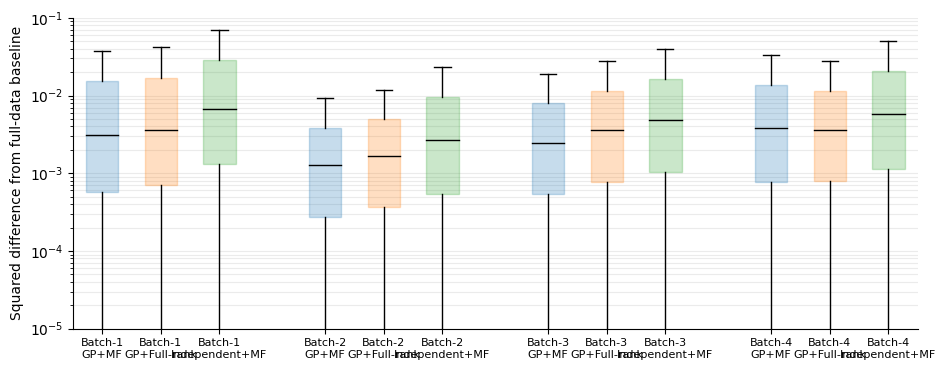

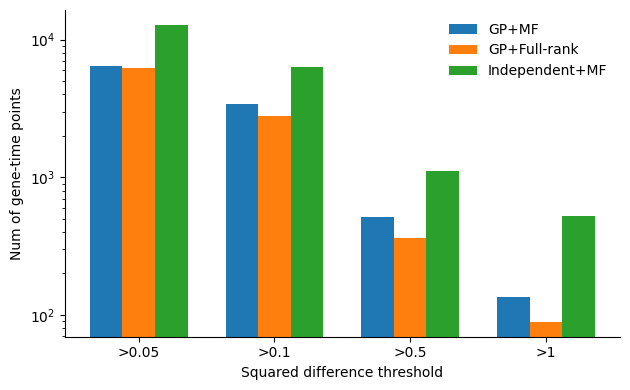

In [10]:
def plot_missing_difference_boxplot(diff_df):
    fig, ax = plt.subplots(figsize=(9.6, 3.8))
    positions = []
    data = []
    labels = []
    pos = 0
    for cohort in cohorts:
        for model_name in MODEL_NAMES:
            vals = diff_df[
                (diff_df["cohort"] == cohort) & (diff_df["model_name"] == model_name)
            ]["squared_difference"].to_numpy()
            data.append(vals[np.isfinite(vals)])
            positions.append(pos)
            labels.append(f"{cohort}\n{MODEL_LABELS[model_name]}")
            pos += 1
        pos += 0.8

    bp = ax.boxplot(data, positions=positions, widths=0.55, patch_artist=True, showfliers=False)
    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for i, patch in enumerate(bp["boxes"]):
        color = default_colors[i % len(MODEL_NAMES)]
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
        patch.set_edgecolor(color)
    for median in bp["medians"]:
        median.set_color("black")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(1e-5, 1e-1)
    ax.set_ylabel("Squared difference from full-data baseline")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.25, which="both")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def plot_threshold_counts(diff_df, thresholds=THRESHOLDS):
    count_rows = []
    for threshold in thresholds:
        for model_name in MODEL_NAMES:
            count_rows.append({
                "threshold": threshold,
                "model_name": model_name,
                "model_label": MODEL_LABELS[model_name],
                "n_gene_time_points": int((diff_df.loc[diff_df["model_name"] == model_name, "squared_difference"] > threshold).sum()),
            })
    count_df = pd.DataFrame(count_rows)

    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    x = np.arange(len(thresholds))
    width = 0.24
    for i, model_name in enumerate(MODEL_NAMES):
        sub = count_df[count_df["model_name"] == model_name]
        ax.bar(x + (i - 1) * width, sub["n_gene_time_points"], width=width, label=MODEL_LABELS[model_name])
    ax.set_xticks(x)
    ax.set_xticklabels([f">{t:g}" for t in thresholds])
    ax.set_yscale("log")
    ax.set_xlabel("Squared difference threshold")
    ax.set_ylabel("Num of gene-time points")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()
#     return count_df


plot_missing_difference_boxplot(diff_df)
threshold_count_df = plot_threshold_counts(diff_df)

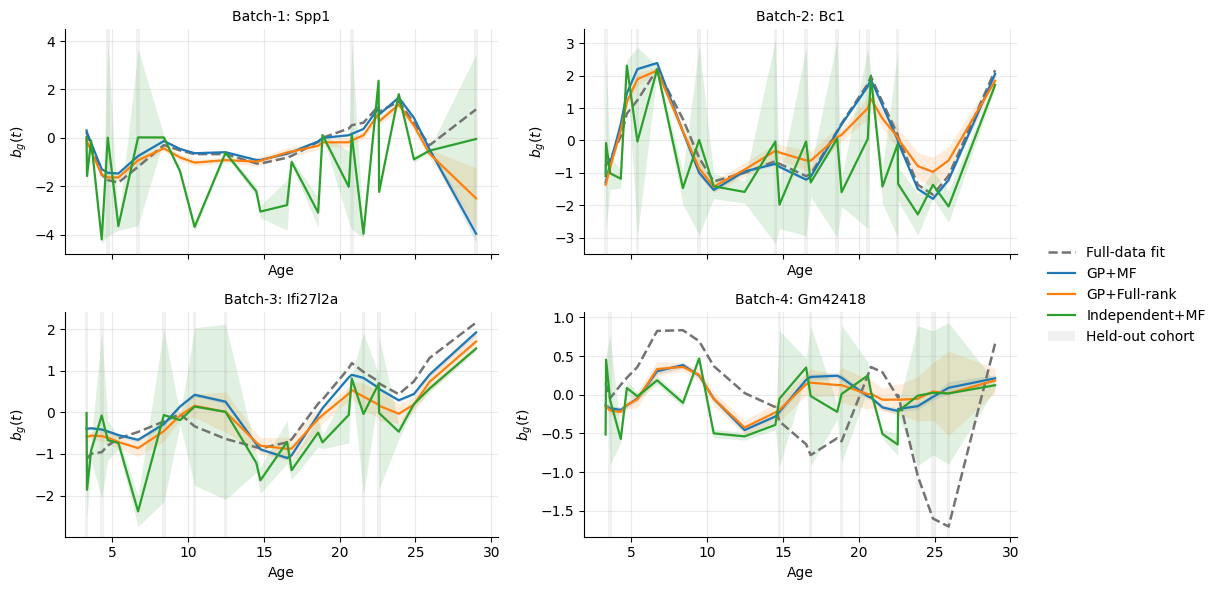

In [9]:
def plot_one_gene_per_batch(baseline_results, leave_results, example_genes=EXAMPLE_GENES):
    fig, axes = plt.subplots(2, 2, figsize=(10.4, 6.0), sharex=True)
    axes = axes.ravel()
    ages = time_points["age"].to_numpy(dtype=float)
    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, cohort in zip(axes, cohorts):
        gene = example_genes.get(cohort)
        if gene not in fit_genes:
            ax.set_title(f"{cohort}: {gene} not fit")
            ax.axis("off")
            continue

        heldout_times = cohort_time_indices[cohort]
        for t in heldout_times:
            age = float(time_points.loc[time_points["time_index"] == t, "age"].iloc[0])
            ax.axvspan(age - 0.12, age + 0.12, color="0.7", alpha=0.18, linewidth=0, zorder=0)

        baseline_b = b_mean_frame(baseline_results["GP_MF"])
        ax.plot(
            ages,
            baseline_b.loc[gene].to_numpy(),
            color="0.45",
            linestyle="--",
            linewidth=1.8,
            label="Full-data fit",
            zorder=4,
        )

        for i, model_name in enumerate(MODEL_NAMES):
            leave_b = b_mean_frame(leave_results[cohort][model_name])
            leave_sd = b_sd_frame(leave_results[cohort][model_name])
            mean = leave_b.loc[gene].to_numpy()
            sd = leave_sd.loc[gene].to_numpy()
            color = default_colors[i]
            ax.plot(ages, mean, color=color, linewidth=1.6, label=MODEL_LABELS[model_name], zorder=5)
            ax.fill_between(ages, mean - 1.96 * sd, mean + 1.96 * sd, color=color, alpha=0.14, linewidth=0, zorder=1)

        ax.set_title(f"{cohort}: {gene}", fontsize=10)
        ax.set_xlabel("Age")
        ax.set_ylabel(r"$b_g(t)$")
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    handles = [
        Line2D([0], [0], color="0.45", linestyle="--", linewidth=1.8, label="Full-data fit"),
        Line2D([0], [0], color=default_colors[0], linewidth=1.6, label=MODEL_LABELS["GP_MF"]),
        Line2D([0], [0], color=default_colors[1], linewidth=1.6, label=MODEL_LABELS["GP_Full-rank"]),
        Line2D([0], [0], color=default_colors[2], linewidth=1.6, label=MODEL_LABELS["Indep_MF"]),
        Patch(facecolor="0.7", alpha=0.18, label="Held-out cohort"),
    ]
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
    fig.tight_layout()
    plt.show()


plot_one_gene_per_batch(baseline_results, leave_results)